# Spatiotemporal Simulation Analysis - Time-Aware

This notebook analyzes simulation output with proper datetime handling and spatiotemporal validation.

**Key Features:**
- Reads datetime from simulation config (start date + tick minutes)
- Time-aware population dynamics with seasonal patterns
- Spatiotemporal KDE maps with temporal filtering
- Stage duration estimation from timestamps
- Environmental lag analysis with datetime indexing
- Validation against occurrence records with temporal matching

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy.stats import pearsonr, spearmanr
from sklearn.neighbors import KernelDensity
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import gaussian_filter
import rasterio
import re
from rasterio.transform import from_origin
import os
import warnings
from collections import defaultdict
import yaml
from datetime import datetime, timedelta
import matplotlib.dates as mdates
from concurrent.futures import ThreadPoolExecutor, as_completed
from functools import partial
from scipy.spatial import cKDTree

warnings.filterwarnings('ignore')

# ======================================================================
# CONFIGURATION - UPDATE THESE PATHS
# ======================================================================
INPUT_FILE = "/home/void/Documents/codes/monadvsim/results/sim_data_20260908_000451.csv"
SIMULATION_CONFIG_PATH = "/home/void/Documents/codes/monadvsim/src/main/resources/config/simulation.yaml"
STUDY_AREA_FILE = "/home/void/Documents/codes/monadvsim/prepared_data/somali/somali.shp"
OUTPUT_DIR = "/mnt/monadworld/projects/phd/article_manuscripts/new/manuscript3/figs"
OCCURRENCE_FILE = "/home/void/Documents/codes/monadvsim/prepared_data/ethiopia_occurrence/merged_observations.csv"

TICKS_PER_DAY = 96
CHUNKSIZE = 100000
MAX_SPATIAL_POINTS_PER_TICK = 100000
STAGE_COLORS = {'ADULT': '#2E8B57', 'LARVA': '#4169E1', 'PUPA': '#FF8C00'}
KDE_BANDWIDTH_DEG = 0.002
KDE_GRID_RES = 150

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuration ready.")

Configuration ready.


In [2]:
# ======================================================================
# 1. Load Simulation Configuration and Parameters
# ======================================================================

def load_simulation_config(config_path):
    """Load simulation configuration from YAML file."""
    if not os.path.exists(config_path):
        print(f"WARNING: Config file not found: {config_path}")
        return None
    with open(config_path, 'r') as f:
        return yaml.safe_load(f)

def get_simulation_time_params(config):
    """Extract start date and tick minutes from config."""
    if config is None or 'time' not in config:
        print("WARNING: No time config found. Using defaults.")
        return datetime(2020, 1, 1, 0, 0, 0), 15
    
    time_config = config['time']
    start_date_str = time_config.get('startDateTime', '2020-01-01T00:00:00')
    tick_minutes = time_config.get('tickMinutes', 15)
    
    # Parse start date
    try:
        start_date = datetime.fromisoformat(start_date_str.replace('Z', '+00:00')).replace(tzinfo=None)
    except ValueError:
        try:
            start_date = datetime.strptime(start_date_str, "%Y-%m-%d %H:%M:%S")
        except ValueError:
            start_date = datetime.strptime(start_date_str.split('T')[0], "%Y-%m-%d")
    
    return start_date, tick_minutes

def tick_to_datetime(tick, start_date, tick_minutes):
    """Convert tick ID to datetime."""
    return start_date + timedelta(minutes=int(tick) * tick_minutes)

# Load config
config = load_simulation_config(SIMULATION_CONFIG_PATH)
START_DATE, TICK_MINUTES = get_simulation_time_params(config)
print(f"Simulation start date: {START_DATE.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Tick minutes: {TICK_MINUTES}")

# Load species parameters
params_species = config.get('species', {}) if config else {}
if not params_species:
    params_species = {
        'egg_dev_rho': 0.005, 'egg_dev_k': 39.2084, 'egg_dev_Delta': 2.0, 'egg_dev_lambda': -0.8549,
        'larva_dev_a': 2.705e-5, 'larva_dev_Tmin': 5.123, 'larva_dev_Tmax': 45.0, 'larva_dev_m': 1.663,
        'pupa_dev_rho': 0.0051, 'pupa_dev_k': 39.94, 'pupa_dev_Delta': 2.0, 'pupa_dev_lambda': -0.9082,
        'egg_mort_b1': 3.5729, 'egg_mort_b2': -0.3235, 'egg_mort_b3': 0.00494,
        'larva_mort_b1': 2.0, 'larva_mort_b2': -0.7395, 'larva_mort_b3': 0.01749,
        'pupa_mort_b1': 5.8826, 'pupa_mort_b2': -0.5785, 'pupa_mort_b3': 0.00946,
        'adult_mort_b1': -1.4775, 'adult_mort_b2': -0.1377, 'adult_mort_b3': 0.00391,
        'adult_mortality_per_day': 0.1198,
        'fecundity_rmax': 1.6022, 'fecundity_Topt': 30.634, 'fecundity_c': -0.00527,
        'sex_ratio': 0.5, 'host_carrying_capacity_base': 1.0,
    }

print("Species parameters loaded.")

Simulation start date: 2020-01-01 00:00:00
Tick minutes: 15
Species parameters loaded.


In [3]:
# ======================================================================
# 2. Load Study Area and Occurrence Data
# ======================================================================

# Load study area with proper CRS
study_area = None
study_area_bounds = None
if os.path.exists(STUDY_AREA_FILE):
    study_area = gpd.read_file(STUDY_AREA_FILE)
    if study_area.crs is None:
        study_area = study_area.set_crs("EPSG:4326")
    elif study_area.crs.to_epsg() != 4326:
        study_area = study_area.to_crs("EPSG:4326")
    study_area_bounds = study_area.total_bounds
    print(f"Study area bounds: {study_area_bounds}")

# Load occurrences with temporal information
occurrences = None
if os.path.exists(OCCURRENCE_FILE):
    occ_df = pd.read_csv(OCCURRENCE_FILE)
    print(f"Occurrence columns: {occ_df.columns.tolist()}")
    print(f"Occurrence sample (first 5 rows):\n{occ_df.head()}")
    
    if 'longitude' in occ_df.columns and 'latitude' in occ_df.columns:
        occ_gdf = gpd.GeoDataFrame(
            occ_df,
            geometry=gpd.points_from_xy(occ_df.longitude, occ_df.latitude),
            crs="EPSG:4326"
        )
        
        if study_area is not None:
            occ_gdf = gpd.sjoin(occ_gdf, study_area, how='inner', predicate='within')
            if 'index_right' in occ_gdf.columns:
                occ_gdf = occ_gdf.drop(columns='index_right')
            print(f"Points inside study area: {len(occ_gdf)}")
        
        if 'date' in occ_gdf.columns:
            occ_gdf['datetime'] = pd.to_datetime(occ_gdf['date'], errors='coerce')
        elif 'year' in occ_gdf.columns:
            occ_gdf['datetime'] = pd.to_datetime(occ_gdf['year'].astype(str) + '-01-01', errors='coerce')
            occ_gdf = occ_gdf.dropna(subset=['datetime'])
        else:
            occ_gdf['datetime'] = pd.Timestamp('2020-01-01')
        
        occurrences = occ_gdf
        print(f"\nLoaded {len(occurrences)} occurrence points after filtering.")
        
        if not occurrences.empty:
            print(f"Date range: {occurrences['datetime'].min()} to {occurrences['datetime'].max()}")
        else:
            print("WARNING: No occurrence points found after filtering!")
    else:
        print("ERROR: Required columns 'longitude' and 'latitude' not found.")

Study area bounds: [39.09111796  3.40667    47.98824    11.09707999]
Occurrence columns: ['longitude', 'latitude', 'year', 'month', 'source']
Occurrence sample (first 5 rows):
   longitude   latitude  year  month       source
0  44.277000   6.735000  2016    NaN         GBIF
1  44.270000   6.730000  2016    NaN         GBIF
2  44.266666   6.733333  2016    NaN         GBIF
3  44.322832   6.927264  2016    NaN  2024.GZ.ROC
4  40.646800  10.166000  2018    NaN         GBIF
Points inside study area: 30

Loaded 30 occurrence points after filtering.
Date range: 2016-01-01 00:00:00 to 2021-01-01 00:00:00


In [4]:
# ======================================================================
# 3. Data Loading with Time-Aware Processing
# ======================================================================

sample = pd.read_csv(INPUT_FILE, nrows=5)
all_cols = sample.columns.tolist()
print(f"Available columns: {all_cols[:10]}...")

ENV_VARS = []
for col in all_cols:
    if 't2m' in col.lower() or 'temp' in col.lower():
        ENV_VARS.append((col, 'Temperature', '°C', 'K', lambda x: x - 273.15))
    elif 'tp' in col.lower() or 'precip' in col.lower():
        ENV_VARS.append((col, 'Precipitation', 'mm', 'm', lambda x: x * 1000))
    elif 'building' in col.lower():
        ENV_VARS.append((col, 'BuildingDensity', 'count', 'count', lambda x: x))
    elif 'population' in col.lower():
        ENV_VARS.append((col, 'Population', 'people', 'people', lambda x: x))

if not ENV_VARS:
    ENV_VARS = [
        ('t2m', 'Temperature', '°C', 'K', lambda x: x - 273.15),
        ('tp', 'Precipitation', 'mm', 'm', lambda x: x * 1000),
        ('Buildings', 'BuildingDensity', 'count', 'count', lambda x: x),
        ('Population', 'Population', 'people', 'people', lambda x: x),
    ]

print(f"Environment variables: {[v[0] for v in ENV_VARS]}")

Available columns: ['TickCount', 'AgentID', 'Layer', 'AgentType', 'X', 'Y', 'Alive', 'Age', 'Stage', 'Energy']...
Environment variables: ['Buildings', 'Population', 't2m', 'tp']


In [5]:
# ======================================================================
# 4. Time-Aware Data Aggregation
# ======================================================================

def aggregate_time_aware(filepath, start_date, tick_minutes, chunksize=CHUNKSIZE):
    """Aggregate data with datetime indexing."""
    
    daily_data = defaultdict(lambda: {
        'adults': 0, 'larvae': 0, 'pupae': 0,
        'tank_count': 0, 'total_water': 0, 'water_count': 0,
        'total_eggs': 0, 'total_larvae': 0,
        'env_sums': {col: 0 for col, _, _, _, _ in ENV_VARS},
        'env_counts': {col: 0 for col, _, _, _, _ in ENV_VARS},
        'tick_counts': []
    })
    
    living_base_cols = ['TickCount', 'Stage', 'AgentID']
    env_col_names = [v[0] for v in ENV_VARS]
    living_cols = living_base_cols + env_col_names
    inert_cols = ['TickCount', 'AgentID', 'waterVolume', 'EggCount', 'LarvaCount']
    
    print("Starting time-aware aggregation...")
    chunk_iter = pd.read_csv(filepath, chunksize=chunksize, low_memory=False)
    
    for i, chunk in enumerate(chunk_iter):
        if i % 10 == 0:
            print(f"  Processing chunk {i}...")
        
        living_mask = chunk['AgentType'] == 'LivingAgent'
        avail_cols = [c for c in living_cols if c in chunk.columns]
        living = chunk.loc[living_mask, avail_cols].copy()
        if not living.empty:
            living['Day'] = (living['TickCount'] // TICKS_PER_DAY).astype('int32')
            for day, grp in living.groupby('Day'):
                daily_data[day]['adults'] += (grp['Stage'] == 'ADULT').sum()
                daily_data[day]['larvae'] += (grp['Stage'] == 'LARVA').sum()
                daily_data[day]['pupae'] += (grp['Stage'] == 'PUPA').sum()
                daily_data[day]['tick_counts'].extend(grp['TickCount'].unique())
                for col, _, _, _, _ in ENV_VARS:
                    if col in grp.columns:
                        daily_data[day]['env_sums'][col] += grp[col].sum()
                        daily_data[day]['env_counts'][col] += len(grp)
        
        inert_mask = chunk['AgentType'] == 'InertAgent'
        avail_cols = [c for c in inert_cols if c in chunk.columns]
        inert = chunk.loc[inert_mask, avail_cols].copy()
        if not inert.empty:
            inert['Day'] = (inert['TickCount'] // TICKS_PER_DAY).astype('int32')
            for day, grp in inert.groupby('Day'):
                daily_data[day]['tank_count'] += grp['AgentID'].nunique()
                if 'waterVolume' in grp.columns:
                    valid = grp['waterVolume'][grp['waterVolume'] >= 0]
                    if not valid.empty:
                        daily_data[day]['total_water'] += valid.sum()
                        daily_data[day]['water_count'] += len(valid)
                if 'EggCount' in grp.columns:
                    daily_data[day]['total_eggs'] += grp['EggCount'].sum()
                if 'LarvaCount' in grp.columns:
                    daily_data[day]['total_larvae'] += grp['LarvaCount'].sum()
    
    days = sorted(daily_data.keys())
    
    df = pd.DataFrame({'Day': days})
    df['DateTime'] = [start_date + timedelta(days=int(d)) for d in days]
    df['AdultCount'] = [daily_data[d]['adults'] for d in days]
    df['LarvaCount'] = [daily_data[d]['larvae'] for d in days]
    df['PupaCount'] = [daily_data[d]['pupae'] for d in days]
    df['TankCount'] = [daily_data[d]['tank_count'] for d in days]
    df['MeanWaterVolume'] = [
        daily_data[d]['total_water'] / max(1, daily_data[d]['water_count']) 
        for d in days
    ]
    df['TotalEggs'] = [daily_data[d]['total_eggs'] for d in days]
    df['TotalLarvae'] = [daily_data[d]['total_larvae'] for d in days]
    
    for col, disp, unit, _, convert in ENV_VARS:
        mean_col = f'Mean{disp}'
        raw_mean = [
            daily_data[d]['env_sums'][col] / max(1, daily_data[d]['env_counts'][col])
            for d in days
        ]
        df[mean_col] = convert(pd.Series(raw_mean)).round(2)
    
    return df

daily_df = aggregate_time_aware(INPUT_FILE, START_DATE, TICK_MINUTES)
print(f"\nAggregated {len(daily_df)} days")
print(f"Date range: {daily_df['DateTime'].min()} to {daily_df['DateTime'].max()}")
print("\nDaily summary head:")
print(daily_df.head())

Starting time-aware aggregation...
  Processing chunk 0...

Aggregated 30 days
Date range: 2020-01-02 00:00:00 to 2020-02-01 00:00:00

Daily summary head:
   Day   DateTime  AdultCount  LarvaCount  PupaCount  TankCount  \
0    1 2020-01-02       11959        4985       3050         17   
1    2 2020-01-03       11951        4984       3047         17   
2    3 2020-01-04       11941        4984       3045         17   
3    4 2020-01-05       11933        4984       3044         17   
4    5 2020-01-06       11927        4983       3042         17   

   MeanWaterVolume  TotalEggs  TotalLarvae  MeanBuildingDensity  \
0        90.347059        975          441                  0.0   
1        88.262353          0         1416                  0.0   
2        85.715882          0         1416                  0.0   
3        99.768235         15         1416                  0.0   
4        99.990588          7         1431                  0.0   

   MeanPopulation  MeanTemperature  Mea

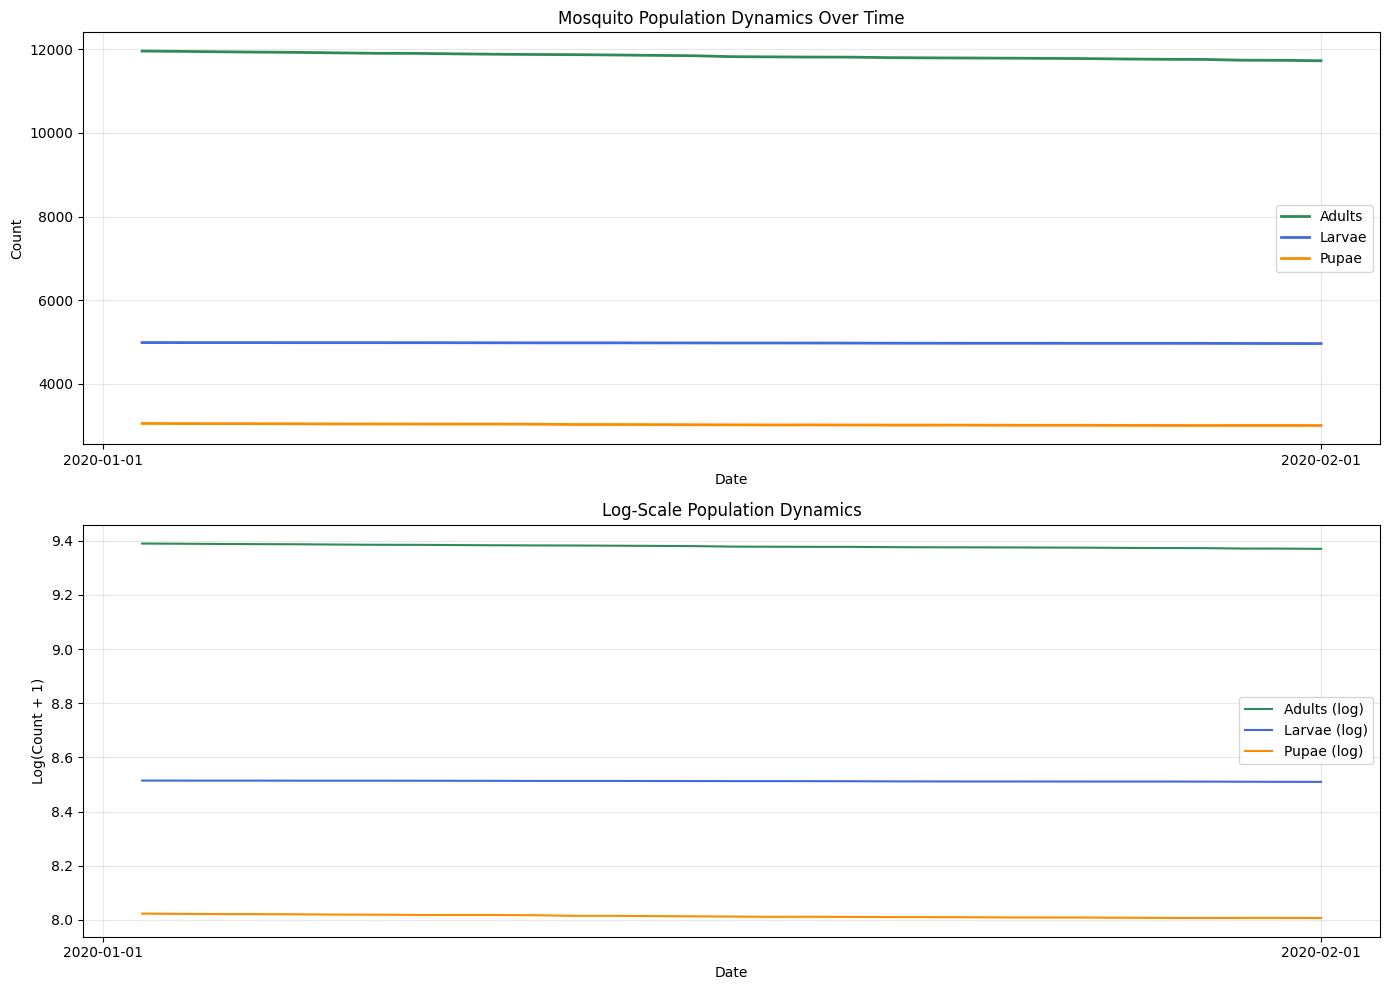

✓ Saved to: /mnt/monadworld/projects/phd/article_manuscripts/new/manuscript3/figs/time_aware_dynamics.png


In [6]:
# ======================================================================
# 5. Time-Aware Population Dynamics
# ======================================================================

def plot_time_aware_dynamics(df, output_dir):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    ax1.plot(df['DateTime'], df['AdultCount'], label='Adults', 
             color=STAGE_COLORS['ADULT'], linewidth=2)
    ax1.plot(df['DateTime'], df['LarvaCount'], label='Larvae', 
             color=STAGE_COLORS['LARVA'], linewidth=2)
    ax1.plot(df['DateTime'], df['PupaCount'], label='Pupae', 
             color=STAGE_COLORS['PUPA'], linewidth=2)
    
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Count')
    ax1.set_title('Mosquito Population Dynamics Over Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(df['DateTime'], np.log1p(df['AdultCount']), 
             label='Adults (log)', color=STAGE_COLORS['ADULT'], linewidth=1.5)
    ax2.plot(df['DateTime'], np.log1p(df['LarvaCount']), 
             label='Larvae (log)', color=STAGE_COLORS['LARVA'], linewidth=1.5)
    ax2.plot(df['DateTime'], np.log1p(df['PupaCount']), 
             label='Pupae (log)', color=STAGE_COLORS['PUPA'], linewidth=1.5)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Log(Count + 1)')
    ax2.set_title('Log-Scale Population Dynamics')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    output_file = f'{output_dir}/time_aware_dynamics.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to: {output_file}")

plot_time_aware_dynamics(daily_df, OUTPUT_DIR)

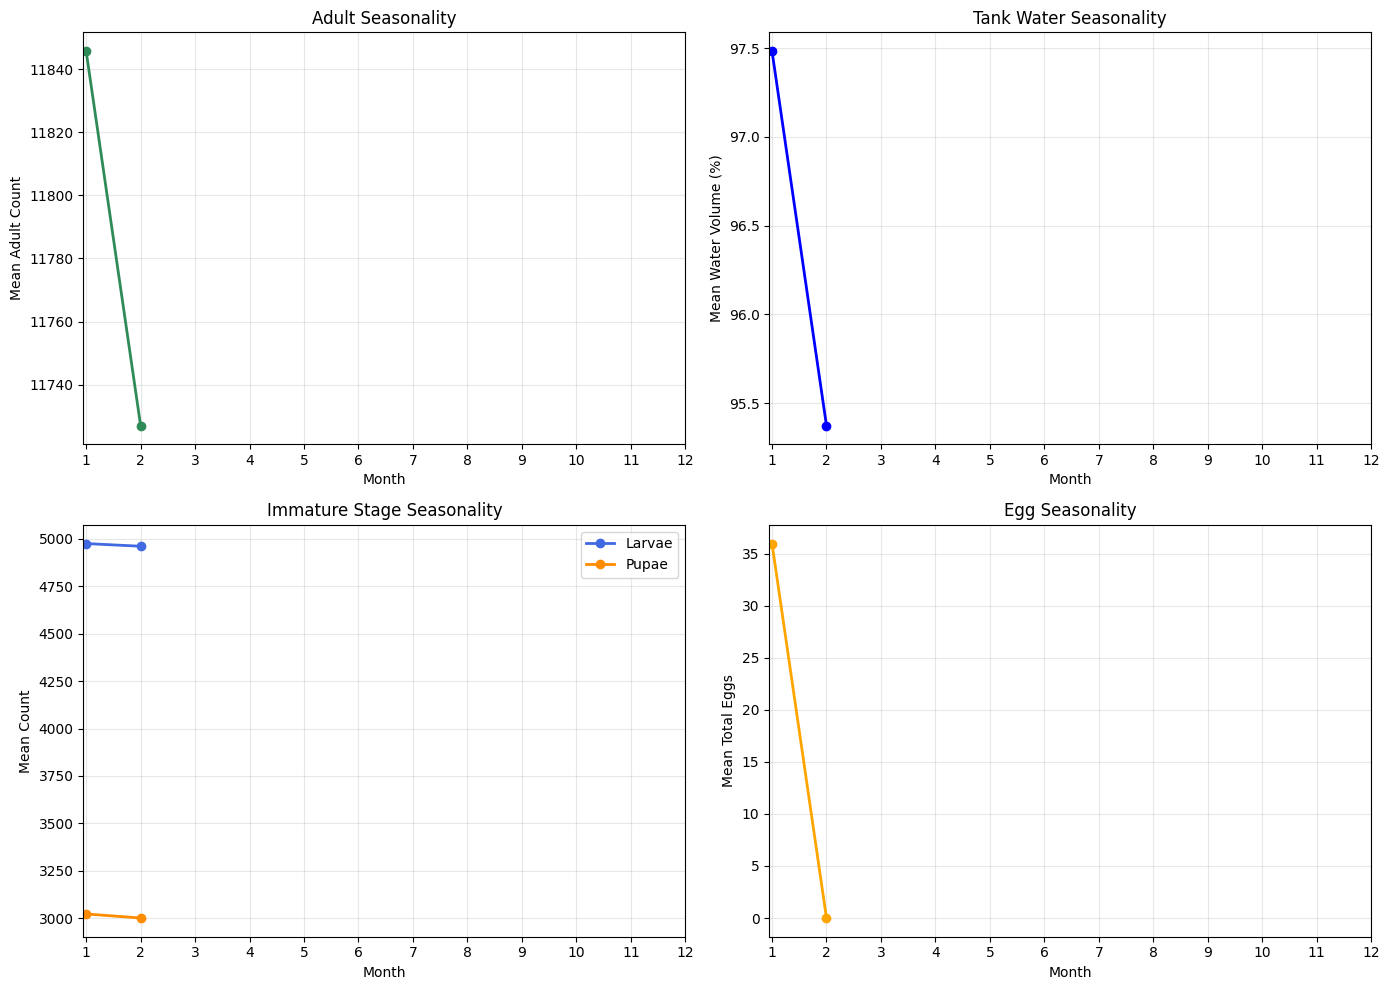


Seasonal Summary:
AdultCount: Peak in month 1, Trough in month 2
LarvaCount: Peak in month 1, Trough in month 2
PupaCount: Peak in month 1, Trough in month 2
TotalEggs: Peak in month 1, Trough in month 2
MeanWaterVolume: Peak in month 1, Trough in month 2


In [7]:
# ======================================================================
# 6. Seasonal Analysis
# ======================================================================

def analyze_seasonal_patterns(df, output_dir):
    df['Month'] = df['DateTime'].dt.month
    df['Week'] = df['DateTime'].dt.isocalendar().week
    df['Year'] = df['DateTime'].dt.year
    
    monthly = df.groupby('Month').agg({
        'AdultCount': 'mean',
        'LarvaCount': 'mean',
        'PupaCount': 'mean',
        'TotalEggs': 'mean',
        'MeanWaterVolume': 'mean'
    }).reset_index()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    ax = axes[0, 0]
    ax.plot(monthly['Month'], monthly['AdultCount'], 'o-', 
            color=STAGE_COLORS['ADULT'], linewidth=2)
    ax.set_xlabel('Month')
    ax.set_ylabel('Mean Adult Count')
    ax.set_title('Adult Seasonality')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(1, 13))
    
    ax = axes[0, 1]
    ax.plot(monthly['Month'], monthly['MeanWaterVolume'], 'o-', 
            color='blue', linewidth=2)
    ax.set_xlabel('Month')
    ax.set_ylabel('Mean Water Volume (%)')
    ax.set_title('Tank Water Seasonality')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(1, 13))
    
    ax = axes[1, 0]
    ax.plot(monthly['Month'], monthly['LarvaCount'], 'o-', 
            color=STAGE_COLORS['LARVA'], linewidth=2, label='Larvae')
    ax.plot(monthly['Month'], monthly['PupaCount'], 'o-', 
            color=STAGE_COLORS['PUPA'], linewidth=2, label='Pupae')
    ax.set_xlabel('Month')
    ax.set_ylabel('Mean Count')
    ax.set_title('Immature Stage Seasonality')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(1, 13))
    
    ax = axes[1, 1]
    ax.plot(monthly['Month'], monthly['TotalEggs'], 'o-', 
            color='orange', linewidth=2)
    ax.set_xlabel('Month')
    ax.set_ylabel('Mean Total Eggs')
    ax.set_title('Egg Seasonality')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(1, 13))
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/seasonal_patterns.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nSeasonal Summary:")
    print("="*50)
    for var in ['AdultCount', 'LarvaCount', 'PupaCount', 'TotalEggs', 'MeanWaterVolume']:
        max_month = monthly.loc[monthly[var].idxmax(), 'Month']
        min_month = monthly.loc[monthly[var].idxmin(), 'Month']
        print(f"{var}: Peak in month {max_month}, Trough in month {min_month}")
    
    return monthly

monthly_seasonal = analyze_seasonal_patterns(daily_df, OUTPUT_DIR)
monthly_seasonal.to_csv(f'{OUTPUT_DIR}/seasonal_summary.csv', index=False)

In [8]:
# ======================================================================
# 7. Spatiotemporal KDE with Temporal Slicing
# ======================================================================

def load_and_filter_chunk(chunk, tick_min, tick_max, stages):
    """Process a single chunk and return filtered points by stage."""
    living = chunk[chunk['AgentType'] == 'LivingAgent']
    if living.empty:
        return {stage: np.array([]) for stage in stages}
    
    if tick_min is not None:
        living = living[living['TickCount'] >= tick_min]
    if tick_max is not None:
        living = living[living['TickCount'] < tick_max]
    
    if living.empty:
        return {stage: np.array([]) for stage in stages}
    
    result = {}
    for stage in stages:
        stage_points = living[living['Stage'] == stage][['X', 'Y']].values
        if len(stage_points) > 0:
            result[stage] = stage_points
        else:
            result[stage] = np.array([])
    
    return result

def compute_spatiotemporal_kde(filepath, time_windows, n_workers=4, use_subsampling=True, max_points_per_stage=50000):
    """Compute KDE data for different time windows with parallel processing."""
    
    stages = ['ADULT', 'LARVA', 'PUPA']
    results = {window_name: {stage: None for stage in stages} 
               for window_name, _, _ in time_windows}
    
    print(f"\nProcessing {len(time_windows)} time windows with {n_workers} workers...")
    
    for window_name, tick_min, tick_max in time_windows:
        print(f"\n  Window: {window_name}")
        
        with ThreadPoolExecutor(max_workers=n_workers) as executor:
            process_func = partial(load_and_filter_chunk, 
                                  tick_min=tick_min, 
                                  tick_max=tick_max,
                                  stages=stages)
            
            chunk_iter = pd.read_csv(filepath, chunksize=CHUNKSIZE, low_memory=False)
            futures = []
            for chunk in chunk_iter:
                if not chunk.empty:
                    futures.append(executor.submit(process_func, chunk))
            
            stage_points = {stage: [] for stage in stages}
            for future in as_completed(futures):
                result = future.result()
                for stage in stages:
                    if len(result[stage]) > 0:
                        stage_points[stage].append(result[stage])
        
        for stage in stages:
            if stage_points[stage]:
                pts = np.vstack(stage_points[stage])
                
                if use_subsampling and len(pts) > max_points_per_stage:
                    indices = np.random.choice(len(pts), max_points_per_stage, replace=False)
                    pts = pts[indices]
                    print(f"    {stage}: {len(pts):,} points (subsampled)")
                else:
                    print(f"    {stage}: {len(pts):,} points")
                
                results[window_name][stage] = pts
            else:
                results[window_name][stage] = np.array([])
    
    return results

def compute_kde_fast(points, grid_x, grid_y, bandwidth=None, use_approx=False):
    """Fast KDE computation with optional approximation."""
    if len(points) < 10:
        return None
    
    if bandwidth is None:
        n = len(points)
        std_x, std_y = np.std(points[:, 0]), np.std(points[:, 1])
        std_mean = np.mean([std_x, std_y])
        bandwidth = max(0.008, 1.06 * std_mean * (n ** (-1/5)))
    
    try:
        kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian', 
                           algorithm='auto', metric='euclidean')
        kde.fit(points)
        
        mesh_x, mesh_y = np.meshgrid(grid_x, grid_y)
        grid_points = np.vstack([mesh_x.ravel(), mesh_y.ravel()]).T
        
        log_dens = kde.score_samples(grid_points)
        density = np.exp(log_dens).reshape(mesh_x.shape)
        density = gaussian_filter(density, sigma=0.8)
        
        return density
    except Exception as e:
        print(f"      KDE failed: {e}")
        return None

def plot_temporal_kde_comparison(kde_results, study_area, occurrences, output_dir, 
                                 figsize=(18, 20), dpi=200):
    """Plot KDE maps for each time window."""
    
    stages = ['ADULT', 'LARVA', 'PUPA']
    windows = list(kde_results.keys())
    n_windows = len(windows)
    
    if study_area is not None:
        minx, miny, maxx, maxy = study_area.total_bounds
        x_pad = (maxx - minx) * 0.05
        y_pad = (maxy - miny) * 0.05
        minx, miny, maxx, maxy = minx - x_pad, miny - y_pad, maxx + x_pad, maxy + y_pad
    else:
        minx, miny, maxx, maxy = 39.0, 3.0, 48.0, 12.0
    
    grid_x = np.linspace(minx, maxx, KDE_GRID_RES)
    grid_y = np.linspace(miny, maxy, KDE_GRID_RES)
    
    fig, axes = plt.subplots(n_windows, len(stages), 
                             figsize=figsize, 
                             dpi=dpi,
                             sharex=True, sharey=True)
    
    if n_windows == 1:
        axes = axes.reshape(1, -1)
    
    occ_coords = None
    if occurrences is not None and not occurrences.empty:
        occ_coords = np.column_stack([occurrences.geometry.x.values, 
                                      occurrences.geometry.y.values])
    
    print("\nGenerating KDE plots...")
    
    for row, window_name in enumerate(windows):
        kde_data = kde_results[window_name]
        
        match = re.search(r'\((\d+)-(\d+)\)', window_name)
        if match:
            tick_min = int(match.group(1))
            tick_max = int(match.group(2))
            start_dt = START_DATE + timedelta(minutes=int(tick_min) * TICK_MINUTES)
            end_dt = START_DATE + timedelta(minutes=int(tick_max) * TICK_MINUTES)
            date_label = f"{start_dt.strftime('%d %b')} → {end_dt.strftime('%d %b %Y')}"
        else:
            date_label = window_name
        
        for col, stage in enumerate(stages):
            ax = axes[row, col]
            
            points = kde_data.get(stage)
            if points is not None and len(points) > 10:
                density = compute_kde_fast(points, grid_x, grid_y)
                
                if density is not None:
                    im = ax.imshow(density, extent=[minx, maxx, miny, maxy],
                                  origin='lower', cmap='YlOrRd', aspect='auto',
                                  interpolation='bilinear', alpha=0.85)
                    
                    if study_area is not None:
                        study_area.boundary.plot(ax=ax, color='black', 
                                                linewidth=0.6, alpha=0.6)
                    
                    if occ_coords is not None:
                        if len(occ_coords) > 200:
                            idx = np.random.choice(len(occ_coords), 200, replace=False)
                            plot_coords = occ_coords[idx]
                        else:
                            plot_coords = occ_coords
                        
                        ax.scatter(plot_coords[:, 0], plot_coords[:, 1],
                                  color='blue', s=10, alpha=0.5, 
                                  edgecolor='white', linewidth=0.2)
                    
                    if col == len(stages) - 1:
                        plt.colorbar(im, ax=ax, label='Density', 
                                   fraction=0.046, pad=0.04)
            else:
                ax.text(0.5, 0.5, 'Insufficient\nPoints',
                       transform=ax.transAxes, ha='center', va='center',
                       fontsize=10, color='gray')
            
            ax.set_title(f'{date_label}\n{stage}', fontsize=11)
            if row == n_windows - 1:
                ax.set_xlabel('Longitude', fontsize=10)
            if col == 0:
                ax.set_ylabel('Latitude', fontsize=10)
            ax.tick_params(labelsize=8)
    
    plt.tight_layout()
    output_file = f'{output_dir}/temporal_kde_comparison.png'
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved KDE comparison to: {output_file}")
    
    return fig

# ======================================================================
# RUN THE KDE ANALYSIS
# ======================================================================

print("=" * 60)
print("SPATIOTEMPORAL KDE ANALYSIS")
print("=" * 60)

time_windows = [
    ('Early (0-750)', 0, 750),
    ('Mid-early (750-1500)', 750, 1500),
    ('Mid-late (1500-2250)', 1500, 2250),
    ('Late (2250-3000)', 2250, 3000),
]

print("\n[1/2] Computing KDE data...")
kde_results = compute_spatiotemporal_kde(
    filepath=INPUT_FILE,
    time_windows=time_windows,
    n_workers=4,
    use_subsampling=True,
    max_points_per_stage=50000
)

print("\n[2/2] Generating KDE plots...")
fig = plot_temporal_kde_comparison(
    kde_results=kde_results,
    study_area=study_area,
    occurrences=occurrences,
    output_dir=OUTPUT_DIR
)

print("\n" + "=" * 60)
print("SUMMARY - Points per window/stage")
print("=" * 60)
for window_name, data in kde_results.items():
    print(f"\n{window_name}:")
    for stage, points in data.items():
        if points is not None:
            print(f"  {stage}: {len(points):,} points")

print("\n✅ KDE analysis complete!")

SPATIOTEMPORAL KDE ANALYSIS

[1/2] Computing KDE data...

Processing 4 time windows with 4 workers...

  Window: Early (0-750)
    ADULT: 50,000 points (subsampled)
    LARVA: 34,886 points
    PUPA: 21,305 points

  Window: Mid-early (750-1500)
    ADULT: 50,000 points (subsampled)
    LARVA: 34,854 points
    PUPA: 21,207 points

  Window: Mid-late (1500-2250)
    ADULT: 50,000 points (subsampled)
    LARVA: 39,780 points
    PUPA: 24,111 points

  Window: Late (2250-3000)
    ADULT: 50,000 points (subsampled)
    LARVA: 34,761 points
    PUPA: 21,024 points

[2/2] Generating KDE plots...

Generating KDE plots...
✓ Saved KDE comparison to: /mnt/monadworld/projects/phd/article_manuscripts/new/manuscript3/figs/temporal_kde_comparison.png

SUMMARY - Points per window/stage

Early (0-750):
  ADULT: 50,000 points
  LARVA: 34,886 points
  PUPA: 21,305 points

Mid-early (750-1500):
  ADULT: 50,000 points
  LARVA: 34,854 points
  PUPA: 21,207 points

Mid-late (1500-2250):
  ADULT: 50,000 poi

In [9]:
# ======================================================================
# 8. Stage Duration Estimation
# ======================================================================

def estimate_stage_duration(filepath, start_date, tick_minutes, output_dir):
    """Estimate duration of each stage from timestamps."""
    
    agent_data = defaultdict(lambda: {'ticks': [], 'stages': []})
    
    chunk_iter = pd.read_csv(filepath, chunksize=CHUNKSIZE, low_memory=False)
    for chunk in chunk_iter:
        living = chunk[chunk['AgentType'] == 'LivingAgent']
        if living.empty:
            continue
        
        for _, row in living.iterrows():
            aid = row['AgentID']
            agent_data[aid]['ticks'].append(row['TickCount'])
            agent_data[aid]['stages'].append(row['Stage'])
    
    durations = {'LARVA': [], 'PUPA': [], 'ADULT': []}
    
    for aid, data in agent_data.items():
        if len(data['ticks']) < 3:
            continue
        
        sorted_data = sorted(zip(data['ticks'], data['stages']))
        
        for i in range(len(sorted_data) - 1):
            current_stage = sorted_data[i][1]
            next_stage = sorted_data[i+1][1]
            if current_stage != next_stage:
                if current_stage in durations and current_stage != 'ADULT':
                    duration_ticks = sorted_data[i+1][0] - sorted_data[i][0]
                    duration_days = duration_ticks / TICKS_PER_DAY
                    durations[current_stage].append(duration_days)
    
    print("\n" + "="*60)
    print("STAGE DURATION ESTIMATES")
    print("="*60)
    
    duration_summary = {}
    for stage, values in durations.items():
        if values:
            duration_summary[stage] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'median': np.median(values),
                'min': np.min(values),
                'max': np.max(values),
                'n': len(values)
            }
            print(f"\n{stage}:")
            print(f"  Mean: {np.mean(values):.2f} days (±{np.std(values):.2f})")
            print(f"  Median: {np.median(values):.2f} days")
            print(f"  Range: {np.min(values):.2f} - {np.max(values):.2f} days")
            print(f"  n = {len(values)}")
    
    return duration_summary

duration_summary = estimate_stage_duration(INPUT_FILE, START_DATE, TICK_MINUTES, OUTPUT_DIR)
pd.DataFrame(duration_summary).T.to_csv(f'{OUTPUT_DIR}/stage_durations.csv')


STAGE DURATION ESTIMATES

LARVA:
  Mean: 1.04 days (±0.00)
  Median: 1.04 days
  Range: 1.04 - 1.04 days
  n = 20

PUPA:
  Mean: 1.04 days (±0.00)
  Median: 1.04 days
  Range: 1.04 - 1.04 days
  n = 50


BuildingDensity: Optimal lag = -30 days, correlation = 0.000
Population: Optimal lag = -25 days, correlation = -0.931
Temperature: Optimal lag = -27 days, correlation = -0.966
Precipitation: Optimal lag = -27 days, correlation = -0.909


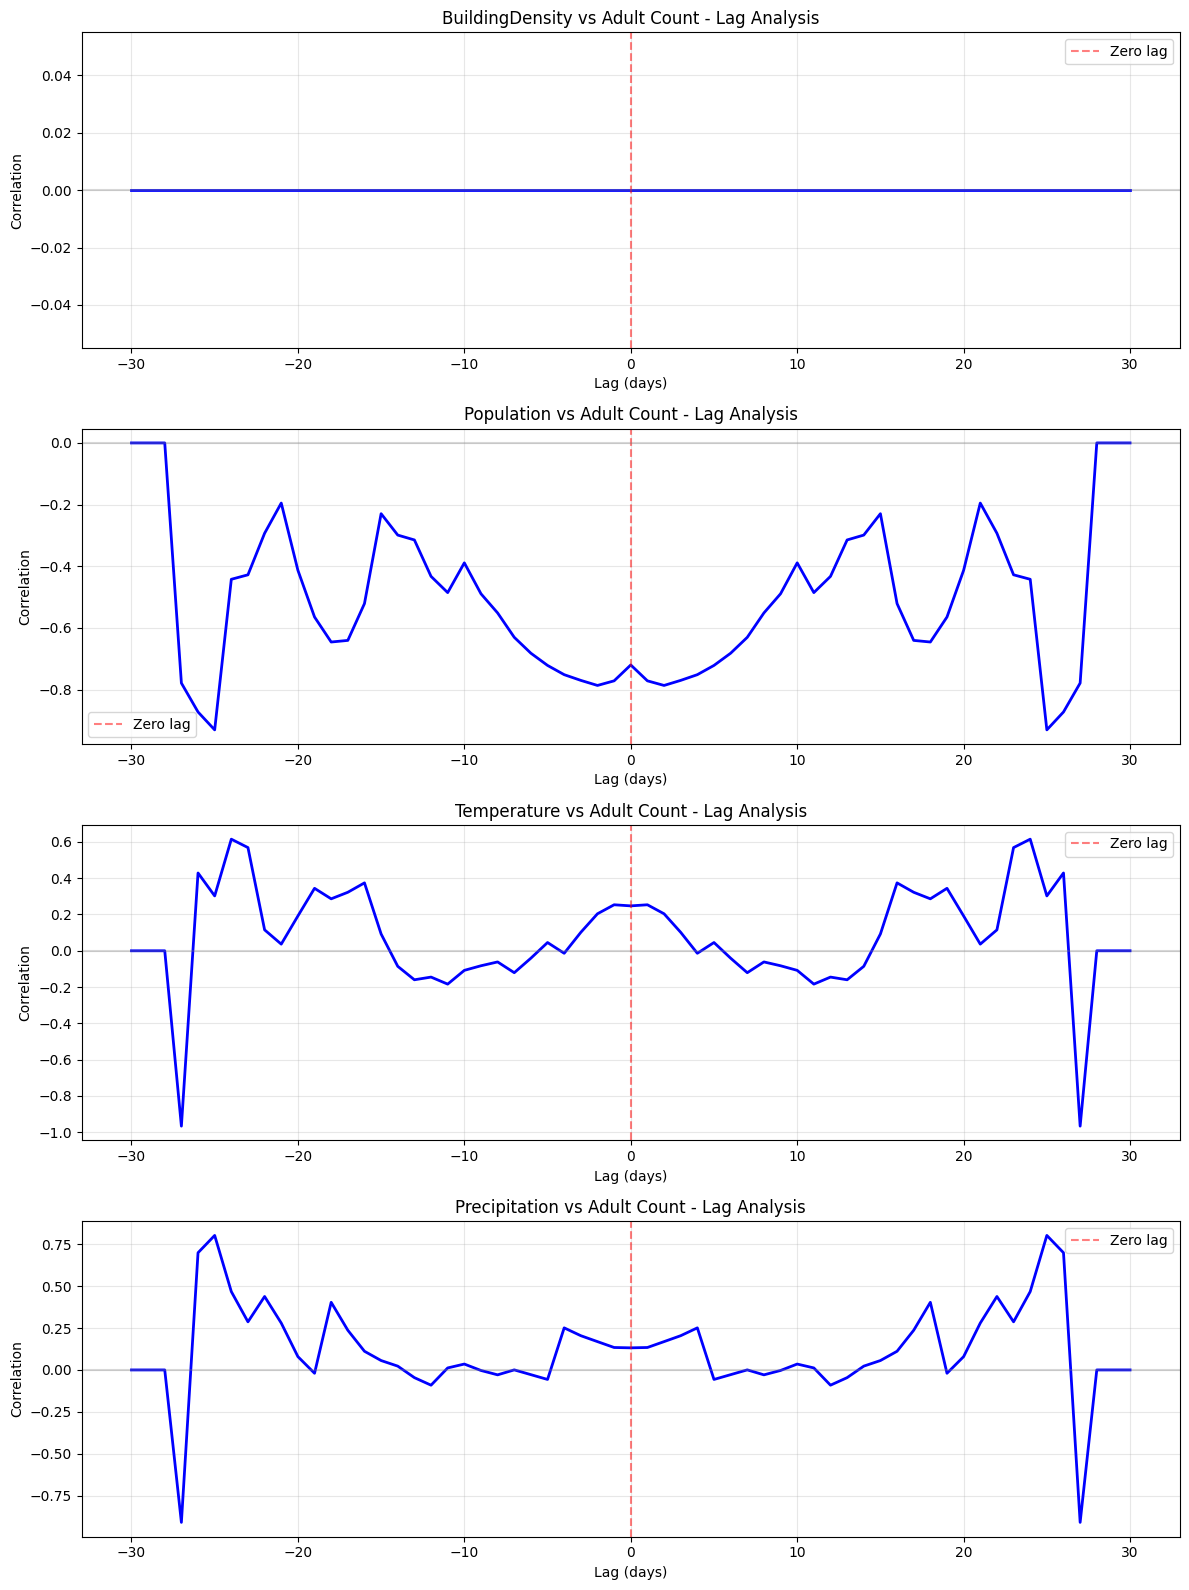

In [10]:
# ======================================================================
# 9. Environmental Lag Analysis with Time Series
# ======================================================================

def analyze_time_series_lags(df, env_vars, max_lag_days=30, output_dir=OUTPUT_DIR):
    """Analyze temporal lags between environment and population."""
    
    var_columns = {}
    for col, disp, unit, _, _ in env_vars:
        mean_col = f'Mean{disp}'
        if mean_col in df.columns:
            var_columns[disp] = mean_col
    
    if not var_columns:
        print("No environmental variables found.")
        return
    
    adult_series = df['AdultCount'].values
    
    fig, axes = plt.subplots(len(var_columns), 1, figsize=(12, 4*len(var_columns)))
    if len(var_columns) == 1:
        axes = [axes]
    
    lag_results = []
    
    for idx, (var_name, col) in enumerate(var_columns.items()):
        var_series = df[col].values
        
        lags = range(-max_lag_days, max_lag_days + 1)
        correlations = []
        
        for lag in lags:
            if lag < 0:
                shifted = adult_series[:lag]
                corr = pearsonr(shifted, var_series[-lag:])[0] if len(shifted) > 2 else 0
            elif lag > 0:
                shifted = adult_series[:-lag]
                corr = pearsonr(shifted, var_series[lag:])[0] if len(shifted) > 2 else 0
            else:
                corr = pearsonr(adult_series, var_series)[0]
            correlations.append(corr if not np.isnan(corr) else 0)
        
        axes[idx].plot(lags, correlations, 'b-', linewidth=2)
        axes[idx].axvline(0, color='r', linestyle='--', alpha=0.5, label='Zero lag')
        axes[idx].axhline(0, color='gray', linestyle='-', alpha=0.3)
        axes[idx].set_xlabel('Lag (days)')
        axes[idx].set_ylabel('Correlation')
        axes[idx].set_title(f'{var_name} vs Adult Count - Lag Analysis')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        
        best_idx = np.argmax(np.abs(correlations))
        best_lag = lags[best_idx]
        best_corr = correlations[best_idx]
        
        lag_results.append({
            'variable': var_name,
            'optimal_lag_days': best_lag,
            'correlation_at_optimal_lag': best_corr
        })
        
        print(f"{var_name}: Optimal lag = {best_lag} days, correlation = {best_corr:.3f}")
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/time_series_lag_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return pd.DataFrame(lag_results)

lag_results = analyze_time_series_lags(daily_df, ENV_VARS, max_lag_days=30)
if lag_results is not None:
    lag_results.to_csv(f'{OUTPUT_DIR}/temporal_lag_results.csv', index=False)


VALIDATION AGAINST OCCURRENCE RECORDS

Validation matches: 66
Valid matches (within 0.05°): 66


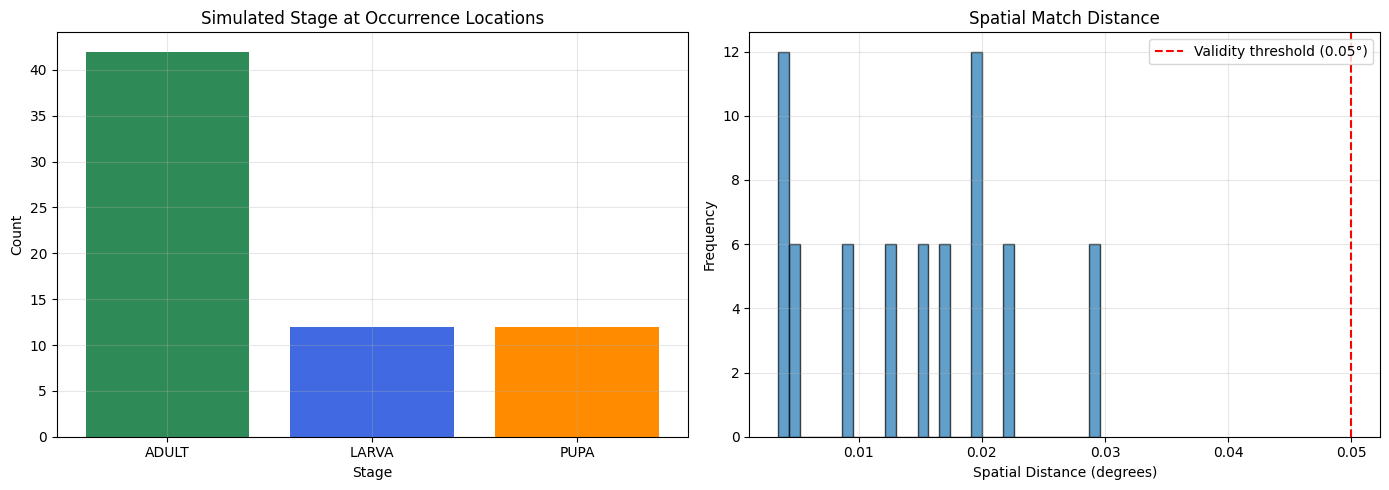

Validation results saved to /mnt/monadworld/projects/phd/article_manuscripts/new/manuscript3/figs/occurrence_validation.csv


In [11]:
# ======================================================================
# 10. Validation Against Occurrence Records
# ======================================================================

def validate_against_occurrences(filepath, occurrences, start_date, tick_minutes, 
                                time_window_days=30, output_dir=OUTPUT_DIR):
    """Validate simulated suitability against occurrence records."""
    
    if occurrences is None or occurrences.empty:
        print("No occurrence data for validation.")
        return
    
    print("\n" + "="*60)
    print("VALIDATION AGAINST OCCURRENCE RECORDS")
    print("="*60)
    
    if 'datetime' not in occurrences.columns:
        print("No datetime information in occurrence records.")
        return
    
    validation_results = []
    
    chunk_iter = pd.read_csv(filepath, chunksize=CHUNKSIZE, low_memory=False)
    
    for chunk in chunk_iter:
        living = chunk[chunk['AgentType'] == 'LivingAgent']
        if living.empty:
            continue
        
        living['DateTime'] = living['TickCount'].apply(
            lambda x: tick_to_datetime(x, start_date, tick_minutes)
        )
        
        for _, occ in occurrences.iterrows():
            occ_time = occ['datetime']
            occ_x = occ.geometry.x
            occ_y = occ.geometry.y
            
            time_mask = (living['DateTime'] >= occ_time - timedelta(days=time_window_days)) & \
                       (living['DateTime'] <= occ_time + timedelta(days=time_window_days))
            
            nearby = living[time_mask]
            if nearby.empty:
                continue
            
            nearby['Distance'] = np.sqrt((nearby['X'] - occ_x)**2 + (nearby['Y'] - occ_y)**2)
            
            closest = nearby.loc[nearby['Distance'].idxmin()]
            
            validation_results.append({
                'occ_date': occ_time,
                'occ_lon': occ_x,
                'occ_lat': occ_y,
                'sim_tick': closest['TickCount'],
                'sim_datetime': closest['DateTime'],
                'sim_distance_deg': closest['Distance'],
                'sim_stage': closest['Stage'],
                'sim_age': closest.get('Age', np.nan),
                'sim_energy': closest.get('Energy', np.nan),
                'valid': closest['Distance'] < 0.05
            })
    
    if not validation_results:
        print("No validation matches found.")
        return
    
    val_df = pd.DataFrame(validation_results)
    
    print(f"\nValidation matches: {len(val_df)}")
    print(f"Valid matches (within 0.05°): {val_df['valid'].sum()}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    valid_stages = val_df[val_df['valid']]['sim_stage'].value_counts()
    ax.bar(valid_stages.index, valid_stages.values, color=['#2E8B57', '#4169E1', '#FF8C00'])
    ax.set_xlabel('Stage')
    ax.set_ylabel('Count')
    ax.set_title('Simulated Stage at Occurrence Locations')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    ax.hist(val_df['sim_distance_deg'], bins=30, alpha=0.7, edgecolor='black')
    ax.axvline(0.05, color='red', linestyle='--', label='Validity threshold (0.05°)')
    ax.set_xlabel('Spatial Distance (degrees)')
    ax.set_ylabel('Frequency')
    ax.set_title('Spatial Match Distance')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/occurrence_validation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    val_df.to_csv(f'{output_dir}/occurrence_validation.csv', index=False)
    print(f"Validation results saved to {output_dir}/occurrence_validation.csv")
    
    return val_df

validation_df = validate_against_occurrences(INPUT_FILE, occurrences, START_DATE, TICK_MINUTES)

In [12]:
# ======================================================================
# 11. Export Results
# ======================================================================

daily_df.to_csv(f'{OUTPUT_DIR}/daily_summary_time_aware.csv', index=False)
print(f"Daily summary saved to {OUTPUT_DIR}/daily_summary_time_aware.csv")

env_summary = pd.DataFrame([{
    'column': v[0], 'display_name': v[1], 'unit': v[2], 'data_type': v[3]
} for v in ENV_VARS])
env_summary.to_csv(f'{OUTPUT_DIR}/environment_columns.csv', index=False)

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"All outputs saved to: {OUTPUT_DIR}")
print("\nOutput files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith('.png') or f.endswith('.csv'):
        print(f"  - {f}")

Daily summary saved to /mnt/monadworld/projects/phd/article_manuscripts/new/manuscript3/figs/daily_summary_time_aware.csv

ANALYSIS COMPLETE
All outputs saved to: /mnt/monadworld/projects/phd/article_manuscripts/new/manuscript3/figs

Output files:
  - daily_summary_time_aware.csv
  - environment_columns.csv
  - occurrence_validation.csv
  - occurrence_validation.png
  - population_with_windows.png
  - seasonal_patterns.png
  - seasonal_summary.csv
  - stage_durations.csv
  - temporal_kde_comparison.png
  - temporal_kde_comparison_dated.png
  - temporal_lag_results.csv
  - time_aware_dynamics.png
  - time_series_lag_analysis.png
